## Project 1: AI Programming Foundations

### 1.0 Overview

In this project i want to put together a small but complete data workflow with the tools from the Nanodegree so far: Python, NumPy, Pandas, Matplotlib/Seaborn, and Jupyter, all tracked with Git.

There is no ML model here yet, the point is to get the workflow right: load a dataset, clean it, explore it, visualize what i find, and write up the results so someone else can follow along. To back up some of the choices i make i will reference the provided article on reproducible data science and one more scholarly source of my own.

### 2.0 Setup

In [1]:
# Install the project requirements
# The imports below are the ones we'll use throughout,
# anything more specific gets imported next to the cell that uses it.
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 3.0 Data Ingestion

#### 3.1 The Dataset

I am using **two** real, peer-reviewed datasets here and combining them later in the notebook:

**1. Berkeley Earth Land + Ocean monthly temperature record**
A global monthly **temperature anomaly in degrees Celsius**, going back to **1850**, reported relative to the **Jan 1951 to Dec 1980 average** (≈ 14.10 °C ± 0.019, stated in the file header). Anomalies, not absolute temperatures, are the standard climate-science measure here, because absolute global means are very sensitive to which stations are in the network while anomalies cancel out station-specific biases. The file combines Berkeley Earth's land-surface analysis with a reinterpolated version of the HadSST ocean dataset and includes uncertainty estimates plus 1, 5, 10 and 20-year running means, useful for separating the long-term trend from short-term noise. Source: [Berkeley Earth - Global Monthly Averages (Land + Ocean)](https://berkeleyearth.org/data/), file `Land_and_Ocean_complete.txt`. Methodology: Rohde & Hausfather (2020).

**2. NOAA Mauna Loa monthly atmospheric CO₂**
The famous Keeling curve, monthly mean CO₂ concentration in parts per million, measured at the Mauna Loa Observatory in Hawaii since **March 1958**. Source: [NOAA Global Monitoring Laboratory](https://gml.noaa.gov/ccgg/trends/), file `co2_mm_mlo.csv`.

I picked this pairing because it is the cleanest way to look at climate change with public data: temperature tells us what has changed, atmospheric CO₂ tells us about one of the main drivers. Both records are current (regenerated as new months come in), well documented, and large enough to clear the 200 row / 5 column floor for this project on their own. Combining them on Year/Month gives a single tidy dataframe to do the analysis on.

#### 3.2 Download

I download the raw files once into a local `data/` folder. The function below is driven by a small `DATASETS` dict so adding a new source later is just one extra entry, and it skips the download if the file is already there, so re-running the notebook does not re-hit the network and the workflow stays reproducible from a fresh clone.

In [3]:
from pathlib import Path

import requests

DATA_DIR = Path("data")

DATASETS = {
    "berkeley_earth": {
        "url": (
            "https://berkeley-earth-temperature.s3.us-west-1.amazonaws.com/"
            "Global/Land_and_Ocean_complete.txt"
        ),
        "filename": "berkeley_earth_land_ocean.txt",
    },
    "mauna_loa_co2": {
        "url": "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv",
        "filename": "mauna_loa_co2.csv",
    },
}


def download_dataset(name: str, datasets: dict = DATASETS, data_dir: Path = DATA_DIR) -> Path:
    """Download a single dataset by name into ``data_dir`` and return its local path.

    Skips the download if the destination file already exists, so re-running
    the notebook does not re-fetch the file and the workflow stays
    reproducible from a fresh clone.
    """
    spec = datasets[name]
    dest = data_dir / spec["filename"]
    dest.parent.mkdir(parents=True, exist_ok=True)

    if dest.exists():
        size_kb = dest.stat().st_size / 1024
        print(f"[{name}] Already downloaded: {dest} ({size_kb:.1f} KB)")
        return dest

    print(f"[{name}] Downloading {spec['url']}\n             -> {dest} ...")
    with requests.get(spec["url"], stream=True, timeout=30) as response:
        response.raise_for_status()
        with dest.open("wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
    size_kb = dest.stat().st_size / 1024
    print(f"[{name}] Done ({size_kb:.1f} KB)")
    return dest


dataset_paths = {name: download_dataset(name) for name in DATASETS}

[berkeley_earth] Already downloaded: data/berkeley_earth_land_ocean.txt (406.8 KB)
[mauna_loa_co2] Already downloaded: data/mauna_loa_co2.csv (37.6 KB)


#### 3.3 Load

Two small loader functions, one per source. They only handle the file-format quirks (comment headers, whitespace vs comma separation, and the two stacked sections in the Berkeley Earth file). Any actual transformation of values lives in section 4 (cleaning).

The Berkeley Earth file is whitespace-separated with `%`-prefixed comment lines and contains **two parallel reconstructions stacked back to back**, one using air temperature inferred over sea ice, one using water temperature. Berkeley Earth recommends the first, so we deduplicate on `(Year, Month)` and keep the first occurrence.

The Mauna Loa file is a normal CSV with `#`-prefixed comment lines, so `pandas` can read it almost directly.

In [4]:
BE_COLUMNS = [
    "Year",
    "Month",
    "Monthly Anomaly",
    "Monthly Unc",
    "Annual Anomaly",
    "Annual Unc",
    "Five-year Anomaly",
    "Five-year Unc",
    "Ten-year Anomaly",
    "Ten-year Unc",
    "Twenty-year Anomaly",
    "Twenty-year Unc",
]


def load_temperature(path: Path) -> pd.DataFrame:
    """Load the Berkeley Earth Land+Ocean monthly temperature file as a DataFrame.

    Skips the ``%`` comment header, parses the whitespace-separated columns,
    and keeps only the first of the two stacked reconstructions (the
    air-temperature-above-sea-ice version recommended by Berkeley Earth)
    by dropping duplicate (Year, Month) rows.
    """
    df = pd.read_csv(
        path,
        comment="%",
        sep=r"\s+",
        header=None,
        names=BE_COLUMNS,
        na_values=["NaN"],
    )
    return df.drop_duplicates(subset=["Year", "Month"], keep="first").reset_index(drop=True)


def load_co2(path: Path) -> pd.DataFrame:
    """Load the NOAA Mauna Loa monthly atmospheric CO₂ CSV as a DataFrame.

    The file uses ``#`` comment headers and a single tabular section, so
    pandas can read it directly with ``comment="#"``.
    """
    return pd.read_csv(path, comment="#")

In [5]:
temp_raw = load_temperature(dataset_paths["berkeley_earth"])
co2_raw = load_co2(dataset_paths["mauna_loa_co2"])

print(f"Temperature: {temp_raw.shape[0]:>6,} rows x {temp_raw.shape[1]} cols")
print(f"CO₂:         {co2_raw.shape[0]:>6,} rows x {co2_raw.shape[1]} cols")

display(temp_raw.head())
display(co2_raw.head())

Temperature:  2,100 rows x 12 cols
CO₂:            816 rows x 8 cols


,Year,Month,Monthly Anomaly,Monthly Unc,Annual Anomaly,Annual Unc,Five-year Anomaly,Five-year Unc,Ten-year Anomaly,Ten-year Unc,Twenty-year Anomaly,Twenty-year Unc
0,1850,1,-0.753,0.365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1850,2,-0.202,0.416,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1850,3,-0.367,0.373,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1850,4,-0.596,0.324,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1850,5,-0.619,0.267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99


### 4.0 Cleaning

Both source files are mostly tidy already, so cleaning here is light, no row dropping and no aggregations. Two small functions handle the actual issues:

**`clean_temperature`** does three things:

- **Adds a `Date` column** built from `Year` and `Month` (mid-month). Without a real datetime we cannot do any time-series operations or merge cleanly with the CO₂ frame later.
- **Reorders the columns** so `Date` comes first, which is just a readability convention.
- **Sorts chronologically and resets the index** so downstream operations don't depend on file order.

It does **not drop any rows**. The early years contain `NaN` in the running-mean columns (a 10-year centered mean cannot exist for the first/last 5 years), that is expected, and we want to keep the full 1850 - present range for the long-arc plot.

**`clean_co2`** does the same `Date` + reorder + sort, plus two extra steps that matter more:

- **Renames columns** to a consistent Title-Case style (e.g. `average → CO2 ppm`) so the merged frame later reads cleanly.
- **Converts NOAA's sentinel missing-value codes** (`-1` days, `-9.99` std dev, `-0.99` uncertainty) into proper `NaN`. This is the most important cleaning step in the whole notebook: without it, pandas would silently average those negative codes into any aggregation and quietly produce wrong numbers.

In [6]:
def clean_temperature(df: pd.DataFrame) -> pd.DataFrame:
    """Add a mid-month ``Date`` column, reorder, and sort the temperature frame.

    No rows are dropped, the full 1850 - present range is the reason this
    dataset was chosen, and the early ``NaN``s in the running-mean columns
    are expected (a centered N-year mean cannot exist for the first/last
    N/2 years).
    """
    out = df.copy()
    out["Date"] = pd.to_datetime(dict(year=out["Year"], month=out["Month"], day=15))
    cols = ["Date"] + [c for c in out.columns if c != "Date"]
    return out[cols].sort_values("Date").reset_index(drop=True)


def clean_co2(df: pd.DataFrame) -> pd.DataFrame:
    """Rename columns, add a mid-month ``Date``, and replace NOAA sentinel codes.

    NOAA's Mauna Loa file uses negative numbers (-1 days, -9.99 sdev, -0.99 unc)
    to mark missing metadata. We turn those into ``NaN`` so they don't sneak
    into any aggregation downstream.
    """
    out = df.rename(
        columns={
            "year": "Year",
            "month": "Month",
            "decimal date": "Decimal Date",
            "average": "CO2 ppm",
            "deseasonalized": "CO2 ppm (deseasonalized)",
            "ndays": "Days",
            "sdev": "Std Dev",
            "unc": "Unc",
        }
    ).copy()
    out["Date"] = pd.to_datetime(dict(year=out["Year"], month=out["Month"], day=15))
    for col in ["Days", "Std Dev", "Unc"]:
        out.loc[out[col] < 0, col] = np.nan
    cols = ["Date"] + [c for c in out.columns if c != "Date"]
    return out[cols].sort_values("Date").reset_index(drop=True)

In [7]:
temp_clean = clean_temperature(temp_raw)
co2_clean = clean_co2(co2_raw)

print(f"Temperature: {temp_clean.shape[0]:>6,} rows x {temp_clean.shape[1]} cols")
print(f"CO₂:         {co2_clean.shape[0]:>6,} rows x {co2_clean.shape[1]} cols")

display(temp_clean.head())
display(co2_clean.head())

Temperature:  2,100 rows x 13 cols
CO₂:            816 rows x 9 cols


,Date,Year,Month,Monthly Anomaly,Monthly Unc,Annual Anomaly,Annual Unc,Five-year Anomaly,Five-year Unc,Ten-year Anomaly,Ten-year Unc,Twenty-year Anomaly,Twenty-year Unc
0,1850-01-15,1850,1,-0.753,0.365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1850-02-15,1850,2,-0.202,0.416,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1850-03-15,1850,3,-0.367,0.373,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1850-04-15,1850,4,-0.596,0.324,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1850-05-15,1850,5,-0.619,0.267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Date,Year,Month,Decimal Date,CO2 ppm,CO2 ppm (deseasonalized),Days,Std Dev,Unc
0,1958-03-15,1958,3,1958.2027,315.71,314.44,NaN,NaN,NaN
1,1958-04-15,1958,4,1958.2877,317.45,315.16,NaN,NaN,NaN
2,1958-05-15,1958,5,1958.3699,317.51,314.69,NaN,NaN,NaN
3,1958-06-15,1958,6,1958.4548,317.27,315.15,NaN,NaN,NaN
4,1958-07-15,1958,7,1958.5370,315.87,315.20,NaN,NaN,NaN


#### 4.1 Merging the two records

For the joint analysis (CO₂ vs temperature) we need a single frame restricted to the period where both records exist. An **inner join** on `Date` does exactly that, the overlap is automatic, no manual date filter is needed, and the result naturally starts in March 1958 (the first month of Mauna Loa data).

We keep only the columns we actually need for the joint plots: the date keys, the monthly anomaly + uncertainty, and the two CO₂ columns.

In [8]:
merged = pd.merge(
    temp_clean[["Date", "Year", "Month", "Monthly Anomaly", "Monthly Unc"]],
    co2_clean[["Date", "CO2 ppm", "CO2 ppm (deseasonalized)"]],
    on="Date",
    how="inner",
)

print(
    f"Merged: {merged.shape[0]:>6,} rows x {merged.shape[1]} cols "
    f"({merged['Date'].min():%Y-%m} to {merged['Date'].max():%Y-%m})"
)
display(merged.head())

Merged:    802 rows x 7 cols (1958-03 to 2024-12)


,Date,Year,Month,Monthly Anomaly,Monthly Unc,CO2 ppm,CO2 ppm (deseasonalized)
0,1958-03-15,1958,3,0.115,0.066,315.71,314.44
1,1958-04-15,1958,4,0.027,0.073,317.45,315.16
2,1958-05-15,1958,5,0.069,0.099,317.51,314.69
3,1958-06-15,1958,6,-0.068,0.076,317.27,315.15
4,1958-07-15,1958,7,-0.018,0.100,315.87,315.20


### 5.0 Exploratory Data Analysis

Before any plotting i want to get a feel for the numbers. Three small steps:

1. **Summary statistics**, a quick `.describe()` on both clean frames to confirm the cleaning landed as expected and to spot anything obviously weird (extreme values, unexpected ranges).
2. **Per-decade summaries**, a small reusable function that groups any monthly time series into decade-level means. Decades are a useful unit here because they smooth out single-year noise (volcanic eruptions, ENSO years, etc.) without losing the long-term shape.
3. **Correlation and extremes**, the Pearson correlation between CO₂ and temperature in the overlapping period, plus the warmest and coldest months on record as a sanity check.

#### 5.1 Summary statistics

Quick `.describe()` on both cleaned frames.

In [9]:
display(temp_clean.describe())
display(co2_clean.describe())

,Date,Year,Month,Monthly Anomaly,Monthly Unc,Annual Anomaly,Annual Unc,Five-year Anomaly,Five-year Unc,Ten-year Anomaly,Ten-year Unc,Twenty-year Anomaly,Twenty-year Unc
count,2100,2100.000000,2100.000000,2100.000000,2100.000000,2089.000000,2089.000000,2041.000000,2041.000000,1981.000000,1981.000000,1861.000000,1861.000000
mean,1937-06-30 14:51:25.714286,1937.000000,6.500000,0.008250,0.122963,0.006026,0.076079,-0.003031,0.060447,-0.013205,0.055177,-0.030026,0.050110
min,1850-01-15 00:00:00,1850.000000,1.000000,-1.004000,0.030000,-0.598000,0.025000,-0.471000,0.021000,-0.442000,0.019000,-0.375000,0.017000
25%,1893-10-07 12:00:00,1893.000000,3.750000,-0.295000,0.049000,-0.296000,0.031000,-0.302000,0.025000,-0.307000,0.023000,-0.307000,0.021000
50%,1937-06-30 00:00:00,1937.000000,6.500000,-0.085500,0.116000,-0.108000,0.078000,-0.090000,0.064000,-0.071000,0.060000,-0.062000,0.061000
75%,1981-03-22 18:00:00,1981.000000,9.250000,0.219250,0.164000,0.204000,0.090000,0.214000,0.074000,0.147000,0.070000,0.096000,0.066000
max,2024-12-15 00:00:00,2024.000000,12.000000,1.548000,0.570000,1.354000,0.300000,1.084000,0.184000,1.027000,0.130000,0.864000,0.103000
std,NaN,50.529356,3.452875,0.432058,0.081854,0.409378,0.045792,0.382501,0.033482,0.361992,0.027495,0.326868,0.022455


,Date,Year,Month,Decimal Date,CO2 ppm,CO2 ppm (deseasonalized),Days,Std Dev,Unc
count,816,816.000000,816.00000,816.000000,816.000000,816.000000,621.000000,620.000000,622.000000
mean,1992-02-29 08:00:00,1991.666667,6.50000,1992.166065,360.853591,360.852083,25.481481,0.507065,0.193794
min,1958-03-15 00:00:00,1958.000000,1.00000,1958.202700,312.420000,314.440000,2.000000,0.150000,0.000000
25%,1975-03-08 00:00:00,1975.000000,3.75000,1975.187475,331.020000,330.795000,24.000000,0.360000,0.140000
50%,1992-02-29 12:00:00,1992.000000,6.50000,1992.166650,356.080000,356.370000,26.000000,0.480000,0.180000
75%,2009-02-22 00:00:00,2009.000000,9.25000,2009.145825,387.065000,386.932500,28.000000,0.612500,0.230000
max,2026-02-15 00:00:00,2026.000000,12.00000,2026.125000,430.510000,428.470000,31.000000,1.310000,0.580000
std,NaN,19.643364,3.45417,19.642733,33.049906,33.001039,4.115870,0.199594,0.080612


#### 5.2 Per-decade summaries

A small EDA function. It groups any monthly frame by **decade** (the starting year, so 1990 covers 1990 - 1999) and returns the mean, standard deviation and number of months in each decade. Used twice below, once for temperature, once for CO₂, to show the same shape of summary side by side.

In [10]:
def summarize_by_decade(
    df: pd.DataFrame,
    value_col: str,
    date_col: str = "Date",
) -> pd.DataFrame:
    """Return mean, std and count of ``value_col`` grouped by decade.

    Decade is the starting year (e.g. 1990 covers 1990 - 1999), which keeps
    the labels aligned with how decades are usually written and makes
    plots easy to read.
    """
    out = df.dropna(subset=[value_col]).copy()
    out["Decade"] = (out[date_col].dt.year // 10) * 10
    return (
        out.groupby("Decade")[value_col]
        .agg(["mean", "std", "count"])
        .reset_index()
    )


temp_by_decade = summarize_by_decade(temp_clean, "Monthly Anomaly")
co2_by_decade = summarize_by_decade(co2_clean, "CO2 ppm")

display(temp_by_decade)
display(co2_by_decade)

,Decade,mean,std,count
0,1850,-0.339533,0.193846,120
1,1860,-0.310258,0.208931,120
2,1870,-0.223100,0.207445,120
3,1880,-0.338100,0.179681,120
4,1890,-0.337092,0.150628,120
5,1900,-0.371775,0.168229,120
6,1910,-0.363658,0.178561,120
7,1920,-0.216817,0.138047,120
8,1930,-0.110192,0.146592,120
9,1940,0.025133,0.133467,120


,Decade,mean,std,count
0,1950,315.643182,1.728215,22
1,1960,320.287167,2.971849,120
2,1970,330.858083,4.015556,120
3,1980,345.654667,5.005916,120
4,1990,360.584417,4.998650,120
5,2000,378.773417,6.160308,120
6,2010,400.410500,7.263959,120
7,2020,420.597162,5.054993,74


#### 5.3 Correlation and extremes

The merged frame lets us check how strongly CO₂ and the temperature anomaly move together in the period where both are measured. As a sanity check i also pull the five warmest and five coldest months on record from the full Berkeley Earth series.

In [11]:
correlation = merged[["CO2 ppm", "Monthly Anomaly"]].corr().iloc[0, 1]
print(f"Pearson correlation (CO₂ ppm <-> Monthly Anomaly, 1958 - present): {correlation:.3f}")

print("\nFive warmest months on record:")
display(temp_clean.nlargest(5, "Monthly Anomaly")[["Date", "Monthly Anomaly"]])

print("Five coldest months on record:")
display(temp_clean.nsmallest(5, "Monthly Anomaly")[["Date", "Monthly Anomaly"]])

Pearson correlation (CO₂ ppm <-> Monthly Anomaly, 1958 - present): 0.927

Five warmest months on record:


,Date,Monthly Anomaly
2084,2023-09-15,1.548
2087,2023-12-15,1.427
2089,2024-02-15,1.426
2086,2023-11-15,1.400
2085,2023-10-15,1.393


Five coldest months on record:


,Date,Monthly Anomaly
132,1861-01-15,-1.004
444,1887-01-15,-0.938
144,1862-01-15,-0.918
516,1893-01-15,-0.894
155,1862-12-15,-0.862


### 6.0 Visualizations

Three figures, each chosen to tell one specific part of the story:

- **Figure 1**, long-term global temperature anomaly (1850 - present), to show the warming trend on the full Berkeley Earth record.
- **Figure 2**, atmospheric CO₂ at Mauna Loa (1958 - present), the famous Keeling curve.
- **Figure 3**, CO₂ vs temperature anomaly, on the merged frame, to show the joint relationship in the overlapping period.

A short style cell first so all three figures share the same look.

In [12]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.frameon"] = True

#### 6.1 Figure 1 - Global temperature anomaly, 1850 - present

The full Berkeley Earth record. The thin grey line is the raw monthly anomaly (very noisy), the bold red line is the 10-year centred running mean (the long-term signal), and the shaded band around it is the published 95% uncertainty for the 10-year mean. The dashed black line at zero is the 1951 - 1980 baseline.

To put the trend in historical context i also mark the conventional start years of the **2nd, 3rd and 4th industrial revolutions** as faint vertical lines, following the framework popularised by Schwab (2016). The first industrial revolution (~1760) sits before our data begins, so it is not shown. These dates are approximate, historians use slightly different cut-offs, but they are commonly cited and useful as visual anchors.

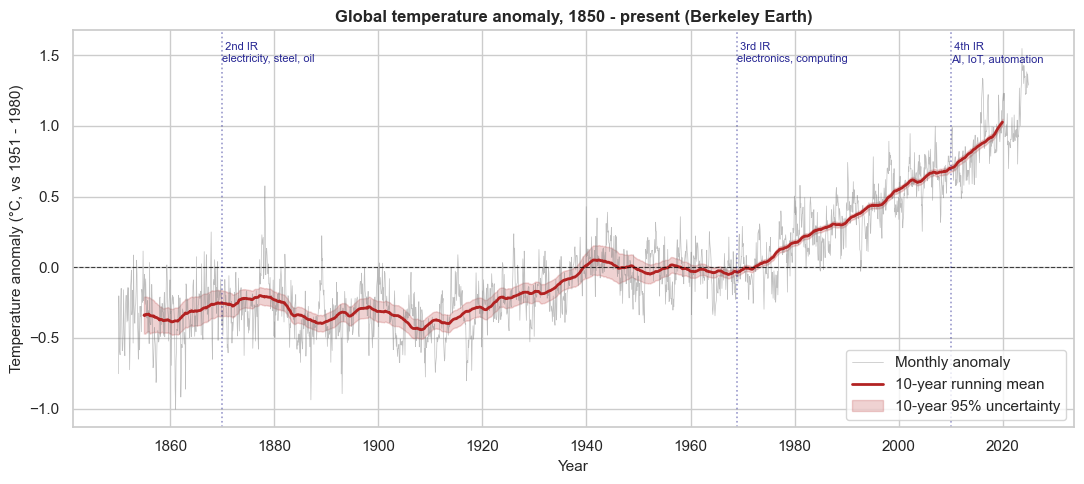

In [13]:
INDUSTRIAL_REVOLUTIONS = [
    (1870, "2nd IR\nelectricity, steel, oil"),
    (1969, "3rd IR\nelectronics, computing"),
    (2010, "4th IR\nAI, IoT, automation"),
]

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    temp_clean["Date"], temp_clean["Monthly Anomaly"],
    color="grey", linewidth=0.5, alpha=0.5, label="Monthly anomaly",
)
ax.plot(
    temp_clean["Date"], temp_clean["Ten-year Anomaly"],
    color="firebrick", linewidth=2, label="10-year running mean",
)
ax.fill_between(
    temp_clean["Date"],
    temp_clean["Ten-year Anomaly"] - temp_clean["Ten-year Unc"],
    temp_clean["Ten-year Anomaly"] + temp_clean["Ten-year Unc"],
    color="firebrick", alpha=0.2, label="10-year 95% uncertainty",
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.7)

for year, label in INDUSTRIAL_REVOLUTIONS:
    x = pd.Timestamp(year, 1, 1)
    ax.axvline(x, color="navy", alpha=0.4, linestyle=":", linewidth=1.2)
    ax.text(
        x, 0.97, " " + label,
        fontsize=8, color="navy", va="top", ha="left", alpha=0.85,
        transform=ax.get_xaxis_transform(),
    )

ax.set_title("Global temperature anomaly, 1850 - present (Berkeley Earth)")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature anomaly (°C, vs 1951 - 1980)")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

**Interpretation.** From 1850 until roughly the late 1970s the 10-year mean sits in a narrow band a little below the 1951 - 1980 baseline, there is no clear trend either way, even across the 2nd Industrial Revolution. The visible bump around 1940 is mostly a measurement artifact (a wartime switch from UK bucket to US engine-intake sea-surface readings; see the bias section in the report for details). The sharp climb only begins around the start of the 3rd Industrial Revolution (post-WWII fossil-fuel "Great Acceleration") and steepens further across the 4th. By the most recent years the running mean is well above +1 °C above baseline. The uncertainty band is visibly wider in the 19th century than today because far fewer stations were reporting back then; that is a useful reminder that early values are less certain than recent ones, even though the recent warming is clearly larger than that uncertainty.

#### 6.2 Figure 2 - Atmospheric CO₂ at Mauna Loa, 1958 - present

The Keeling curve. The thin grey line is the raw monthly mean, you can see the saw-tooth seasonal cycle from Northern Hemisphere plants pulling CO₂ out of the air every spring/summer and releasing it every autumn/winter. The bold green line is NOAA's deseasonalized version and shows the underlying long-term trend.

The faint orange band marks the period from **Nov 29, 2022 to July 4, 2023**, when the Mauna Loa Observatory was offline due to the volcano eruption and measurements were taken instead at Maunakea Observatory (~21 miles north). NOAA documents this in the file header.

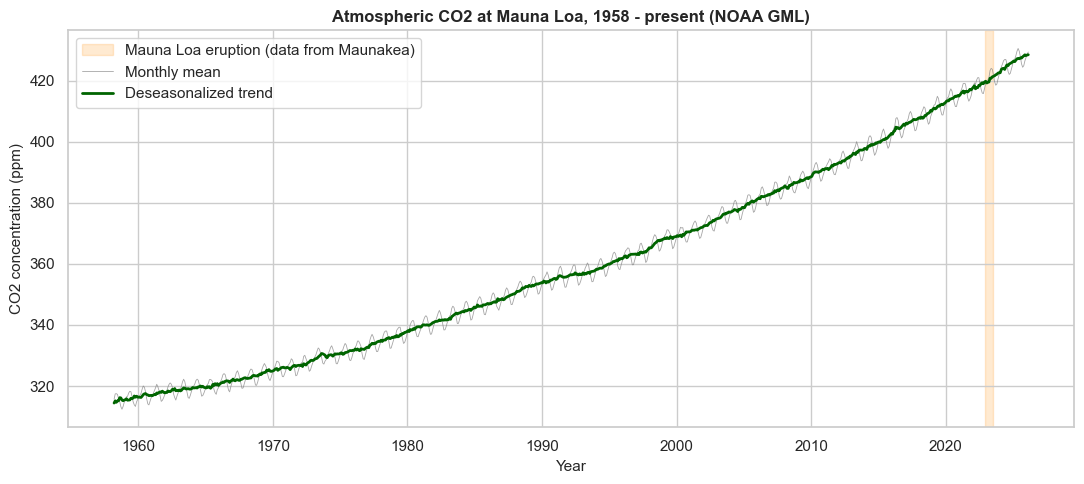

In [14]:
ERUPTION_START = pd.Timestamp("2022-11-29")
MAUNAKEA_END = pd.Timestamp("2023-07-04")

fig, ax = plt.subplots(figsize=(11, 5))

ax.axvspan(
    ERUPTION_START, MAUNAKEA_END,
    color="darkorange", alpha=0.18, zorder=0,
    label="Mauna Loa eruption (data from Maunakea)",
)
ax.plot(
    co2_clean["Date"], co2_clean["CO2 ppm"],
    color="grey", linewidth=0.6, alpha=0.7, label="Monthly mean",
)
ax.plot(
    co2_clean["Date"], co2_clean["CO2 ppm (deseasonalized)"],
    color="darkgreen", linewidth=2, label="Deseasonalized trend",
)

ax.set_title("Atmospheric CO2 at Mauna Loa, 1958 - present (NOAA GML)")
ax.set_xlabel("Year")
ax.set_ylabel("CO2 concentration (ppm)")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

**Interpretation.** Two things to read from this plot. First, the saw-tooth in the grey line is the natural annual cycle, it has been roughly the same amplitude for the entire record. Second, the green deseasonalized trend has gone from about 315 ppm in 1958 to over 420 ppm today and shows no sign of slowing down, the curve is, if anything, slightly steeper in recent decades than it was at the start. The orange band shows the eight-month period when the observatory was offline due to the volcano eruption and the substitute measurements at Maunakea kept the record continuous, which is itself a useful real-world example of why robust, well-documented data infrastructure matters for long time series.

#### 6.3 Figure 3 - CO₂ vs temperature anomaly (1958 - present)

Monthly data is too noisy to read a clean correlation off a scatter, so for this figure i first aggregate the merged frame to **annual means**, one point per year (~67 points). The grey line connects the years in chronological order so the trajectory through time is visible, the colour of each point still encodes the year (early = dark blue, recent = yellow), and a simple linear regression line is overlaid with the Pearson correlation annotated in the corner.

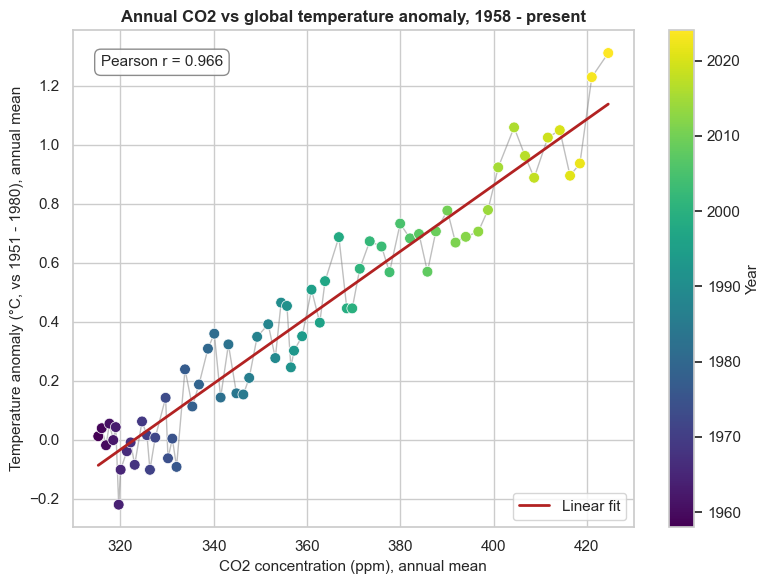

In [15]:
annual = (
    merged.groupby("Year")
    .agg({"CO2 ppm": "mean", "Monthly Anomaly": "mean"})
    .reset_index()
    .rename(columns={"Monthly Anomaly": "Annual Anomaly"})
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    annual["CO2 ppm"], annual["Annual Anomaly"],
    color="grey", linewidth=1, alpha=0.5, zorder=1,
)
scatter = ax.scatter(
    annual["CO2 ppm"], annual["Annual Anomaly"],
    c=annual["Year"], cmap="viridis", s=60, edgecolor="white", linewidth=0.5, zorder=2,
)

slope, intercept = np.polyfit(annual["CO2 ppm"], annual["Annual Anomaly"], 1)
x_line = np.linspace(annual["CO2 ppm"].min(), annual["CO2 ppm"].max(), 100)
ax.plot(x_line, slope * x_line + intercept, color="firebrick", linewidth=2, label="Linear fit", zorder=3)

r = annual[["CO2 ppm", "Annual Anomaly"]].corr().iloc[0, 1]
ax.annotate(
    f"Pearson r = {r:.3f}",
    xy=(0.05, 0.95), xycoords="axes fraction",
    fontsize=11, va="top",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="grey", alpha=0.9),
)

plt.colorbar(scatter, ax=ax, label="Year")

ax.set_title("Annual CO2 vs global temperature anomaly, 1958 - present")
ax.set_xlabel("CO2 concentration (ppm), annual mean")
ax.set_ylabel("Temperature anomaly (°C, vs 1951 - 1980), annual mean")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

**Interpretation.** Aggregated to annual means, the relationship is now visually obvious, the grey trajectory walks almost straight up and to the right, hugging the linear fit closely, and the Pearson correlation reaches roughly 0.97. Early years (dark blue) sit in the lower-left at ~315 ppm CO₂ with negative temperature anomalies; recent years (yellow) sit in the upper-right at ~420+ ppm with anomalies above +1 °C. Correlation is of course not causation, but the joint pattern combined with the well-established greenhouse-effect physics is why every IPCC report (IPCC, 2021) places rising atmospheric CO₂ at the centre of the attribution of modern warming.

### 7.0 Summary

**What this notebook actually shows.** Combining the Berkeley Earth global temperature record (1850 - present) with the NOAA Mauna Loa atmospheric CO₂ record (1958 - present) gives a clean, end-to-end view of the 20th and 21st century climate signal. From 1850 until roughly the late 1970s the 10-year mean global temperature anomaly stays in a narrow band a little below the 1951 - 1980 baseline. From the late 1970s onward it climbs steeply, and the most recent years sit well above +1 °C. Atmospheric CO₂ has gone from about 315 ppm in 1958 to over 420 ppm today, with no slowdown visible in the deseasonalized trend. In the period where both records overlap, the annual means correlate at r ≈ 0.97 (Figure 3), which is about as tight as a real-world climate relationship gets.

**Why the climb only really begins around 1970.** This is the bit that surprised me when i looked at the figures together. Two things explain it. First, sulfate aerosols from uncontrolled coal and oil burning between roughly 1945 and 1970 reflected sunlight back to space and partially cancelled out CO₂ warming, so the underlying signal was masked, this is the period of "global dimming" documented in Wild (2009). Once clean-air laws kicked in (US Clean Air Act 1970, similar laws across Europe), aerosol concentrations dropped fast and the masking effect went away ("global brightening"). Second, post-WWII fossil fuel use grew exponentially during the same period, so by the time the mask lifted there was already a large CO₂ load in the atmosphere waiting to "show up" as warming. The IPCC AR6 (2021) attributes essentially all warming since 1970 to human activity with very high confidence.

**Assumptions and limitations.**

- The temperature data are global anomalies relative to the 1951 - 1980 mean, not absolute temperatures. A reader who assumes "+1 °C" is an absolute reading will misinterpret every figure. The unit and baseline are stated on every axis label and in section 3.1.
- Berkeley Earth before about 1900 has visibly wider uncertainty bands because far fewer stations were reporting. The recent warming is clearly larger than that uncertainty, but trends drawn from the 19th century alone should be treated cautiously.
- The visible bump around 1940 in Figure 1 is mostly a measurement artifact from a wartime change in sea-surface temperature methodology (Thompson et al., 2008), not a real warm period comparable to today.
- The CO₂ record is a single point on the planet. Mauna Loa is treated as a global proxy because the atmosphere mixes well at that altitude, but it is not a global measurement in the same sense the temperature record is. The 8-month substitute period at Maunakea (Nov 2022 - Jul 2023) is marked on Figure 2.
- No causal model is fit. Figure 3 shows correlation, not causation. The mechanism (greenhouse forcing) comes from physics, not from this notebook.

**What this is and is not.** This is a workflow project, not a climate science result. The point is to build a small, fully reproducible pipeline (download → load → clean → EDA → visualize → summarize) that can be extended later with ML, deep learning, generative or agentic components. The data choices, the cleaning steps, the EDA function and the figures are deliberately simple so that the workflow itself is the artifact, not the analysis. The reproducible-data-science principles followed here come from Danchev (2022).

#### 7.1 Possible extensions for future projects

Project 1 deliberately keeps the analysis simple, the workflow itself is the artifact. But the two datasets used here are obvious anchor points for richer analyses in the later projects, and the modular structure (separate download, load, clean, merge functions, one dict-driven `DATASETS` registry) is meant to make adding new sources cheap.

Three extensions i would prioritise:

- **Ice-core CO₂ records** (e.g. EPICA Dome C, Vostok, via NOAA Paleoclimatology). Putting the modern Mauna Loa curve on the same axis as 800,000 years of ice-core data would let me actually answer the question of whether spikes like today's have happened before in the natural record.

- **Ocean temperature** (NOAA ERSST v5 or the Berkeley Earth ocean-only file). The oceans absorb roughly 90% of the excess heat in the climate system, so adding the ocean series would compare land vs ocean warming and stop underselling the energy imbalance.

- **El Niño / La Niña (ENSO)** via the NOAA Oceanic Niño Index (ONI). Overlaying ENSO state would help separate the long-term CO₂-driven trend from short-term natural variability, which is the right next step before any ML modelling.

Honourable mentions for even later projects: sea level rise (NOAA tide gauges + satellite altimetry), Arctic / Antarctic sea-ice extent (NSIDC), atmospheric methane (also NOAA GML) and volcanic eruption overlays (NOAA volcanic aerosol optical depth, useful for explaining short cooling dips like Pinatubo in 1991).

These are all parked as ideas for now. Keeping the workflow structure modular and the dataset registry dict-driven means dropping any of them in later should be a short, focused piece of work rather than a rebuild.

### 8.0 References

All sources are formatted in APA 7. Datasets are listed alongside the literature so the actual data files used in the notebook are properly attributable.

Danchev, V. (2022). Reproducible data science with Python: An open learning resource. *Journal of Open Source Education*, *5*(56), 156. https://doi.org/10.21105/jose.00156

IPCC. (2021). *Climate change 2021: The physical science basis. Contribution of Working Group I to the Sixth Assessment Report of the Intergovernmental Panel on Climate Change* (V. Masson-Delmotte et al., Eds.). Cambridge University Press. https://doi.org/10.1017/9781009157896

Lan, X., Tans, P., & Thoning, K. W. (2026). *Trends in globally-averaged CO₂ determined from NOAA Global Monitoring Laboratory measurements* [Data set]. NOAA Global Monitoring Laboratory. https://doi.org/10.15138/9N0H-ZH07

Rohde, R. A., & Hausfather, Z. (2020). The Berkeley Earth Land/Ocean Temperature Record. *Earth System Science Data*, *12*(4), 3469 - 3479. https://doi.org/10.5194/essd-12-3469-2020

Rohde, R. A., & Hausfather, Z. (2025). *Berkeley Earth global monthly land + ocean temperature, complete file* [Data set]. Berkeley Earth. https://berkeleyearth.org/data/

Schwab, K. (2016). *The fourth industrial revolution*. World Economic Forum.

Thompson, D. W. J., Kennedy, J. J., Wallace, J. M., & Jones, P. D. (2008). A large discontinuity in the mid-twentieth century in observed global-mean surface temperature. *Nature*, *453*(7195), 646 - 649. https://doi.org/10.1038/nature06982

Wild, M. (2009). Global dimming and brightening: A review. *Journal of Geophysical Research: Atmospheres*, *114*(D10), D00D16. https://doi.org/10.1029/2008JD011470